In [1]:
INPUT_DIR = "/home/laurits/tmp/tauDaughterDataset/"

In [2]:
import glob
import os
import numpy as np
import awkward as ak
import matplotlib.pyplot as plt

In [3]:
files = []
for path in glob.glob(os.path.join(INPUT_DIR, "*")):
    data = ak.from_parquet(path)
    data = ak.Array({field: data[field] for field in data.fields})
    files.append(data)
data = ak.concatenate(files, axis=0)

In [4]:
from ntupelizer.tools import ntupelizing as nt


In [5]:
gen_jet_tau_vis_daughter_pdgs = data['gen_jet_tau_vis_daughter_pdgs']
reco_cand_pdgs = data["reco_cand_pdgs"]

In [18]:
# PDG → LaTeX label mapping (candid convention)
PDG_LABELS = {
    211: r"$\pi^\pm$",
    111: r"$\pi^0$",
    321: r"$K^\pm$",
    311: r"$K^0$",
    310: r"$K^0_S$",
    130: r"$K^0_L$",
    11: r"$e^\pm$",
    13: r"$\mu^\pm$",
    22: r"$\gamma$",
    2212: r"$p$",
    2112: r"$n$",
    221: r"$\eta$",
    323: r"$K^{*+}$"
}


def _sig_to_label(sig: tuple) -> str:
    """Convert (211, 211, 130) -> 'π±, π±, K⁰L'."""
    return ", ".join(PDG_LABELS.get(p, str(p)) for p in sig)


def _plot_confusion(matrix, row_labels, col_labels, title="Decay-mode confusion"):
    """Plot confusion matrix with gen on x-axis, reco on y-axis.

    matrix: [n_reco, n_gen]  — rows=reco, cols=gen
    """
    fig, ax = plt.subplots(
        figsize=(max(8, len(col_labels) * 0.45), max(6, len(row_labels) * 0.35))
    )

    im = ax.imshow(matrix, aspect="auto", cmap="Blues", interpolation="nearest")

    # Grid lines at half-integer positions (between cells)
    ax.set_xticks(np.arange(-0.5, len(col_labels), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(row_labels), 1), minor=True)
    ax.grid(which="minor", color="gray", linestyle="-", linewidth=0.5)
    ax.tick_params(which="minor", bottom=False, left=False)

    ax.set_xticks(range(len(col_labels)))
    ax.set_xticklabels(col_labels, rotation=90, fontsize=8, ha="center")
    ax.set_yticks(range(len(row_labels)))
    ax.set_yticklabels(row_labels, fontsize=8)

    ax.set_xlabel("Gen tau visible daughters  (true)")
    ax.set_ylabel("Reco jet constituents  (predicted)")
    ax.set_title(title)

    # Annotate non-zero cells
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            v = matrix[i, j]
            if v > 0:
                color = "white" if v > matrix.max() * 0.5 else "black"
                ax.text(j, i, str(v), ha="center", va="center", fontsize=6, color=color)

    fig.colorbar(im, ax=ax, label="Count")
    fig.tight_layout()
    return fig, ax


# ---------------------------------------------------------------------------
# 1.  Flatten and collect per-jet signatures
# ---------------------------------------------------------------------------

# Gen  side: sorted tuple of visible tau-daughter PDGs (abs to ignore charge)
gen_sigs = []
for jet in gen_jet_tau_vis_daughter_pdgs:
    gen_sigs.append(tuple(sorted(abs(p) for p in jet.to_list())))

# Reco side: sorted tuple of reco-candidate candids (already abs in candid mapping)
reco_sigs = []
for jet in reco_cand_pdgs:
    reco_sigs.append(tuple(sorted(ak.to_list(jet))))

assert len(gen_sigs) == len(reco_sigs), (
    f"Mismatched jet counts: {len(gen_sigs)} gen vs {len(reco_sigs)} reco"
)

# ---------------------------------------------------------------------------
# 2.  Discover all unique signatures from the data
# ---------------------------------------------------------------------------

gen_unique = sorted(set(gen_sigs), key=lambda t: (len(t), t))
reco_unique = sorted(set(reco_sigs), key=lambda t: (len(t), t))

gen_idx = {sig: i for i, sig in enumerate(gen_unique)}
reco_idx = {sig: i for i, sig in enumerate(reco_unique)}

n_gen = len(gen_unique)
n_reco = len(reco_unique)

print(f"Unique gen  signatures: {n_gen}")
print(f"Unique reco signatures: {n_reco}")

# ---------------------------------------------------------------------------
# 3.  Build the confusion matrix
# ---------------------------------------------------------------------------

# Build confusion matrix: rows=reco, cols=gen
matrix = np.zeros((n_reco, n_gen), dtype=int)

for gsig, rsig in zip(gen_sigs, reco_sigs):
    gi = gen_idx[gsig]
    ri = reco_idx[rsig]
    matrix[ri, gi] += 1

# Diagonal fraction
n_matchable = min(n_gen, n_reco)
diag = matrix.trace() if n_matchable > 0 else 0
total = matrix.sum()
print(f"Diagonal: {diag} / {total} = {diag / total * 100:.1f}%")

# ---------------------------------------------------------------------------
# 4.  Report top signatures
# ---------------------------------------------------------------------------

print("\nTop-10 gen signatures by frequency:")
gen_counts = {sig: sum(1 for s in gen_sigs if s == sig) for sig in gen_unique}
for sig, n in sorted(gen_counts.items(), key=lambda x: -x[1])[:10]:
    print(f"  {n:6d}  {sig}")

print("\nTop-10 reco signatures by frequency:")
reco_counts = {sig: sum(1 for s in reco_sigs if s == sig) for sig in reco_unique}
for sig, n in sorted(reco_counts.items(), key=lambda x: -x[1])[:10]:
    print(f"  {n:6d}  {sig}")


Unique gen  signatures: 34
Unique reco signatures: 238
Diagonal: 149 / 7092 = 2.1%

Top-10 gen signatures by frequency:
    2716  (111, 211)
    1215  (211,)
    1042  (211, 211, 211)
    1034  (111, 111, 211)
     458  (111, 211, 211, 211)
     109  (111, 111, 111, 211)
      99  (211, 311)
      83  (321,)
      50  (111, 111, 211, 211, 211)
      44  (111, 211, 311)

Top-10 reco signatures by frequency:
    1631  (22, 22, 211)
    1003  (211,)
     521  (22, 22, 22, 22, 211)
     464  (211, 211, 211)
     400  (22, 22, 22, 211)
     304  (22, 211)
     189  (22, 22, 130, 211)
     156  (130, 211)
     150  (22, 22, 211, 211, 211)
     116  (22, 22, 22, 22, 22, 211)


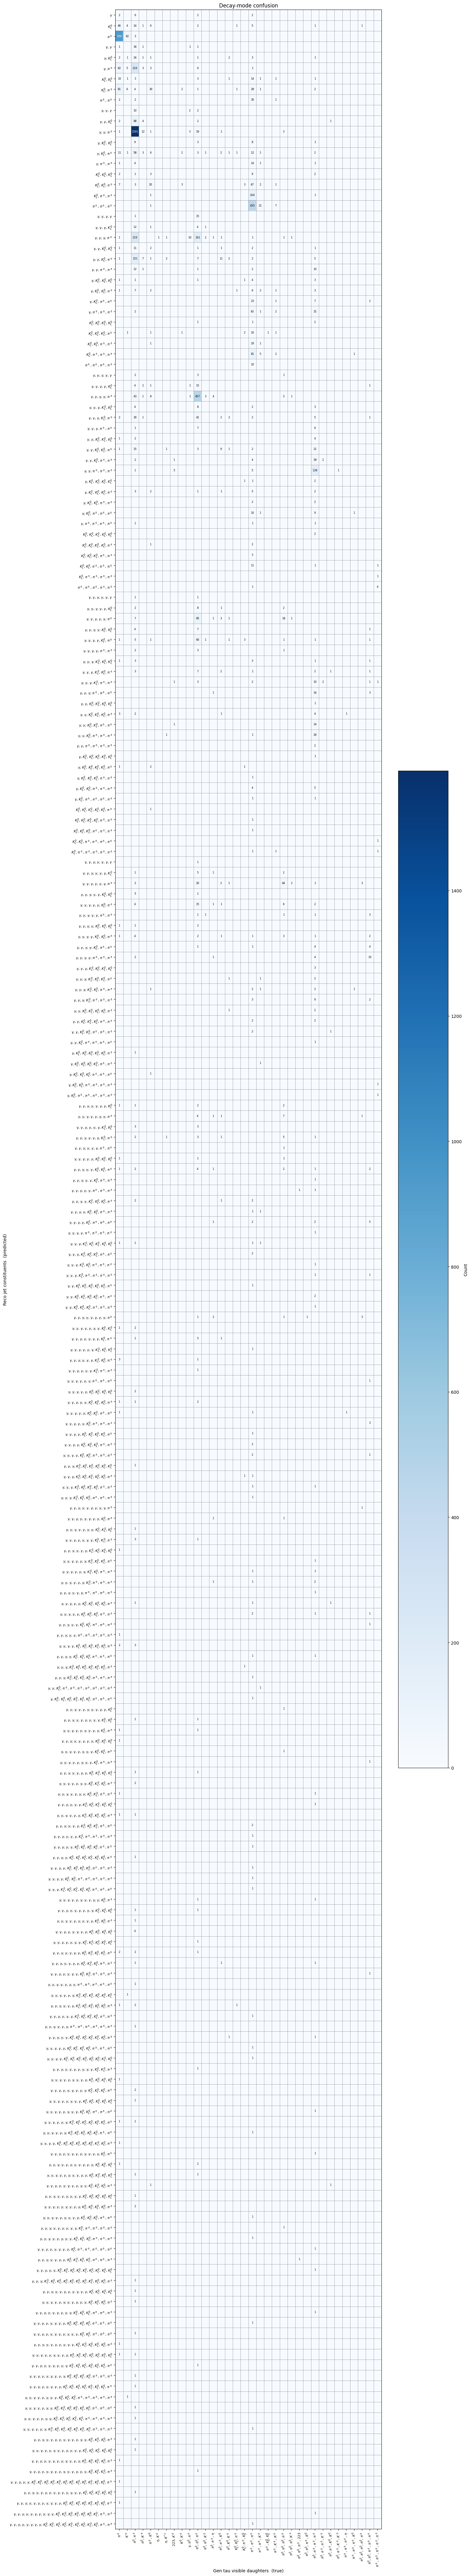

In [19]:
gen_labels = [_sig_to_label(s) for s in gen_unique]
reco_labels = [_sig_to_label(s) for s in reco_unique]

_plot_confusion(matrix, row_labels=reco_labels, col_labels=gen_labels)
plt.savefig("/home/laurits/tmp/tauDaughterDataset/reco_v_gen.pdf")

In [ ]:
# eta meson (PDG=221):
    # q = 0
	# η : 547.862±0.018 MeV/c2[1]
    # η' : 957.78±0.06 MeV/c2[1]
    # Decay modes:
    #     pi+pi-pi0 (23.02%)
    #     pi+pi-gamma (4.28%)
    #     2gamma (39.36%)
    #     3pi0 (32.57%)
    #     pi0 + 2gamma (2.55%)

# K*+ (PDG=323)
    # q = 1
    # m = 892 MeV
    # Decays either to
    #     K^0 + pi+
    # or  K^+ + pi0
